# LAB 05: HOG-Based Industrial Defect Detection and Classification

**Pipeline:** `Image → Preprocessing → HOG Feature Extraction → Machine-Learning Classifier → Defective / Non-Defective Decision`

**Dataset:** NEU Steel Surface Defect (train/valid split) from Kaggle · **Classifiers:** SVM (RBF + Linear), Random Forest, Logistic Regression

### Notebook map (every lab task is covered)
| Section | Lab task(s) |
|---|---|
| 1. Setup & dataset download | – |
| 2. Load & inspect dataset | Task 1 |
| 3. Binary dataset construction, resizing, grayscale | Tasks 2, 3 |
| 4. HOG extraction & visualization | Tasks 4, 5 |
| 5. SVM + additional classifiers, comparison, confusion matrix, metrics | Tasks 6–10 |
| 6. HOG parameter study (cell size × orientations) | Task 11, required experiments |
| 7. Final model | Tasks 9, 10 |
| 8. Multi-class (6 defect types) – advanced | Advanced work |
| 9. Robustness experiments (brightness, noise, rotation, blur) | Task 12 |
| 10. Quality-control decision module | Task 13, required output |
| 11. Bonus: real-time webcam / video prototype | Bonus |
| 12. Report (auto-generated PDF + Markdown) | Report |

> **Important note about the dataset.** NEU-DET contains **only defective** steel-surface images (6 defect types: crazing, inclusion, patches, pitted surface, rolled-in scale, scratches) with XML bounding boxes. It has **no "normal" images**. To still follow the binary formulation (Class 0 = Non-Defective, Class 1 = Defective) the notebook works at **patch level** using the XML annotations:
> * **Class 1 (Defective):** a window centred on every annotated defect box.
> * **Class 0 (Non-Defective):** windows sampled from the *same* steel images that do **not** overlap any annotated defect (clean background steel).
>
> The 6-class problem is solved on the whole images in Section 8 (advanced work). This design choice is documented again in the report's *Limitations* section.

## 1. Setup & Dataset Download

In [ ]:
%pip install -q kagglehub scikit-image scikit-learn opencv-python-headless reportlab pandas matplotlib joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.4 MB/s eta 0:00:00


In [ ]:
import os, re, glob, time, random, warnings, itertools, xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import cv2
import joblib
import matplotlib
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             roc_auc_score)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)


WIN = 80
IMG_SIZE = 64
NORMALS_PER_IMAGE = 3
MAX_NORMAL_OVERLAP = 0.02
CELL_SIZES = [4, 8, 16]
ORIENTATIONS = [6, 9, 12]
BASE_CELL, BASE_ORIENT = 8, 9
BLOCK = 2

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
CLASS_NAMES = ["Non-Defective", "Defective"]

def savefig(name):
    plt.savefig(os.path.join(OUT_DIR, name), dpi=130, bbox_inches="tight")

plt.rcParams.update({"figure.dpi": 100, "axes.grid": False})
print("OpenCV", cv2.__version__, "| numpy", np.__version__)

OpenCV 4.14.0 | numpy 2.1.3


Dataset download (the code you provided). If you already have the dataset on disk, set `LOCAL_DATASET_PATH` to its folder to skip the download.

In [ ]:
LOCAL_DATASET_PATH = None   # e.g. "/content/neu" if you have it locally

if LOCAL_DATASET_PATH:
    path = LOCAL_DATASET_PATH
else:
    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")

print("Path to dataset files:", path)

# quick look at the folder structure (3 levels deep)
for d, subdirs, files in os.walk(path):
    depth = os.path.relpath(d, path).count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(d) + f"/  ({len(files)} files)")

100%|██████████| 26.3M/26.3M [00:00<00:00, 70.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1
1/  (0 files)
valid_images/  (100 files)
valid_annotations/  (100 files)
train_annotations/  (1700 files)
train_images/  (1700 files)


## 2. Load and Inspect the Dataset (Task 1)

In [ ]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")
KNOWN = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]

def get_split(p):
    parts = [x.lower() for x in os.path.relpath(p, path).split(os.sep)]
    for x in parts:
        if x in ("train", "training"): return "train"
        if x in ("valid", "val", "validation", "test"): return "valid"
    return None

def get_class(fname):
    stem = os.path.splitext(fname)[0].lower()
    norm = stem.replace("-", "_")
    for k in KNOWN:
        if norm.startswith(k.replace("-", "_")):
            return k
    return re.sub(r"[_-]?\d+$", "", stem)

xml_index, records = {}, []
for d, _, files in os.walk(path):
    for f in files:
        p = os.path.join(d, f)
        if f.lower().endswith(".xml"):
            xml_index[(get_split(p), os.path.splitext(f)[0])] = p
            xml_index.setdefault((None, os.path.splitext(f)[0]), p)
        elif f.lower().endswith(IMG_EXT):
            records.append(dict(path=p, split=get_split(p), cls=get_class(f), stem=os.path.splitext(f)[0]))

df = pd.DataFrame(records)
assert len(df) > 0, "No images found - check the dataset path."
df["xml"] = [xml_index.get((s, st)) or xml_index.get((None, st)) for s, st in zip(df.split, df.stem)]

# If the dataset has no train/valid folders, create a stratified split
if df.split.isna().all():
    tr, va = train_test_split(df.index, test_size=0.2, stratify=df.cls, random_state=SEED)
    df.loc[tr, "split"] = "train"; df.loc[va, "split"] = "valid"
df = df.dropna(subset=["split"]).reset_index(drop=True)

print(f"Total images: {len(df)} | with XML annotation: {df.xml.notna().sum()}")
display(pd.crosstab(df.cls, df.split, margins=True))

Total images: 1800 | with XML annotation: 1800


split,train,valid,All
cls,,,
crazing,240,60,300
inclusion,240,60,300
patches,240,60,300
pitted_surface,240,60,300
rolled-in_scale,240,60,300
scratches,240,60,300
All,1440,360,1800


Image sizes (H, W) in sample: [(200, 200)]
Average annotated defects per image: 2.33


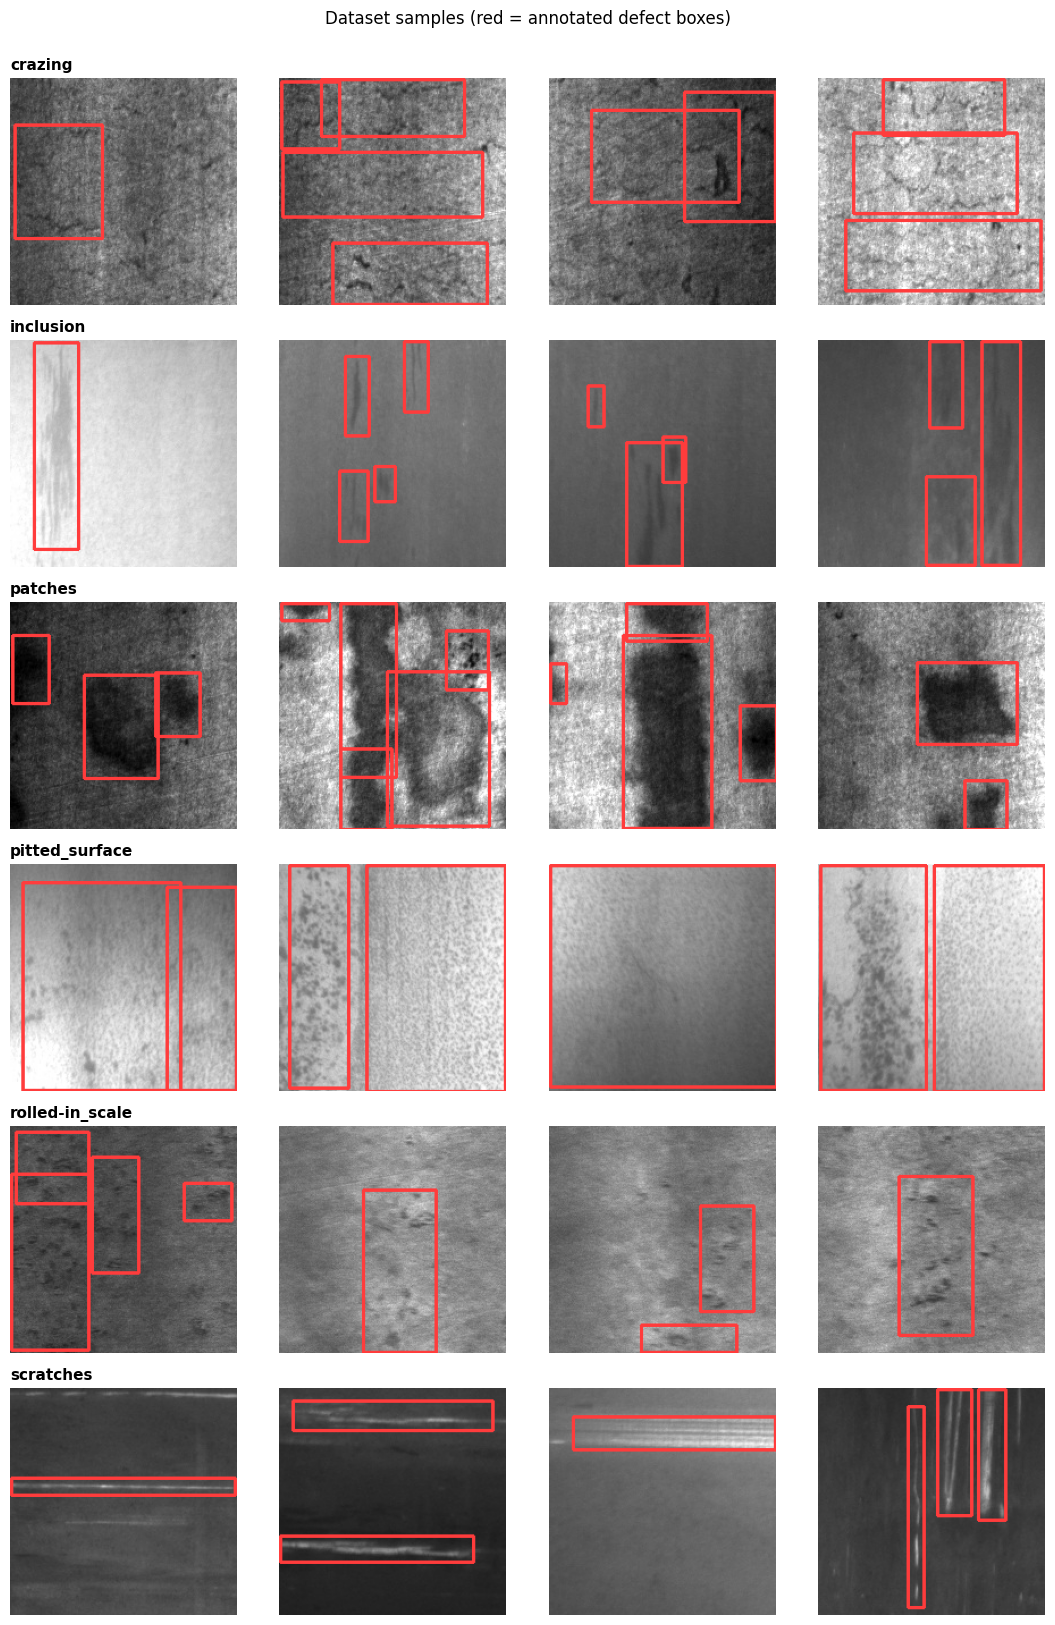

In [ ]:
def parse_boxes(xml_path):
    if not xml_path: return []
    boxes = []
    for obj in ET.parse(xml_path).getroot().findall("object"):
        bb = obj.find("bndbox")
        if bb is None: continue
        boxes.append(tuple(int(float(bb.find(t).text)) for t in ("xmin", "ymin", "xmax", "ymax")))
    return boxes

df["boxes"] = df.xml.apply(parse_boxes)
df["n_boxes"] = df.boxes.apply(len)

# image size statistics (sample)
sizes = [cv2.imread(p).shape[:2] for p in df.path.sample(min(50, len(df)), random_state=SEED)]
print("Image sizes (H, W) in sample:", sorted(set(sizes)))
print("Average annotated defects per image:", round(df.n_boxes.mean(), 2))

# ---- sample images per class with their defect boxes ----
classes_found = sorted(df.cls.unique())
fig, axes = plt.subplots(len(classes_found), 4, figsize=(11, 2.7 * len(classes_found)))
axes = np.atleast_2d(axes)
for r, c in enumerate(classes_found):
    rows = df[(df.cls == c) & (df.split == "train")].sample(4, random_state=SEED)
    for a, (_, row) in zip(axes[r], rows.iterrows()):
        im = cv2.cvtColor(cv2.imread(row.path), cv2.COLOR_BGR2RGB)
        for (x1, y1, x2, y2) in row.boxes:
            cv2.rectangle(im, (x1, y1), (x2, y2), (255, 60, 60), 2)
        a.imshow(im); a.axis("off")
    axes[r][0].set_title(c, loc="left", fontsize=11, fontweight="bold")
plt.suptitle("Dataset samples (red = annotated defect boxes)", y=1.0)
plt.tight_layout(); savefig("dataset_samples.png"); plt.show()

## 3. Binary Dataset Construction, Resizing and Grayscale (Tasks 2 & 3)

Because NEU-DET has no defect-free images, each annotated image yields
* **defective patches** – an `WIN×WIN` window centred on each annotated defect, and
* **non-defective patches** – up to `NORMALS_PER_IMAGE` random windows that do not overlap any defect box.

Every patch is then **converted to grayscale** and **resized to a common resolution** (`IMG_SIZE × IMG_SIZE`).
The provided *train* / *valid* folders are kept as separate image-level splits, so no image appears in both.

Built in 6.9s
TRAIN: (5425, 64, 64) -> normal=2107, defective=3318
TEST : (1374, 64, 64) -> normal=503, defective=871
Sub-train: 4351 | validation (for HOG parameter selection): 1074


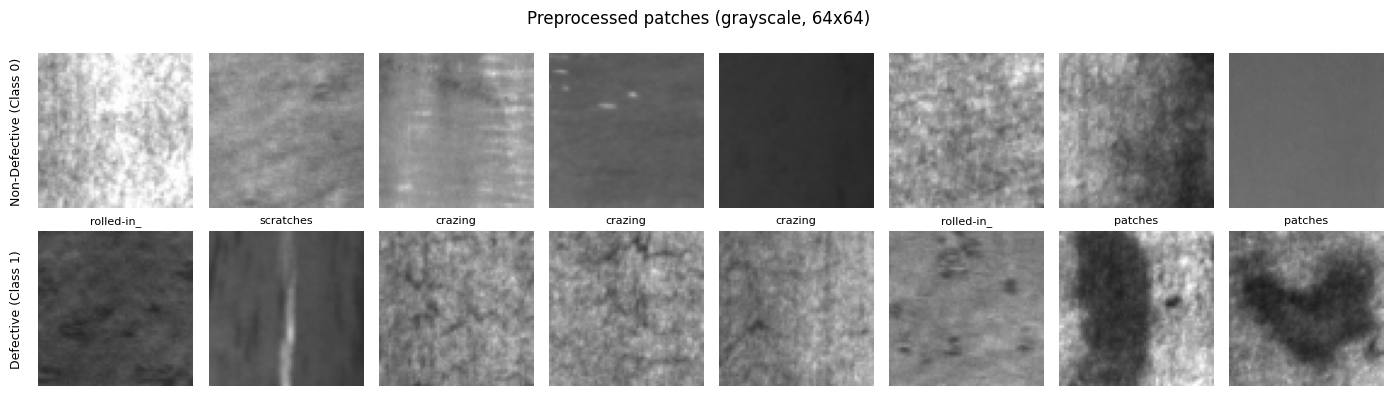

In [ ]:
rng = np.random.default_rng(SEED)

def crop_window(img, cx, cy, win):
    H, W = img.shape[:2]
    w = min(win, W, H)
    x0 = int(np.clip(cx - w // 2, 0, W - w)); y0 = int(np.clip(cy - w // 2, 0, H - w))
    return img[y0:y0 + w, x0:x0 + w], (x0, y0, w)

def overlap_fraction(x0, y0, w, boxes):
    # largest fraction of the window covered by any single defect box
    best = 0.0
    for (bx1, by1, bx2, by2) in boxes:
        iw = max(0, min(x0 + w, bx2) - max(x0, bx1)); ih = max(0, min(y0 + w, by2) - max(y0, by1))
        best = max(best, iw * ih / float(w * w))
    return best

def preprocess(img, size=IMG_SIZE):
    # PREPROCESSING: grayscale -> resize to common resolution (INTER_AREA)
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    return cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA)

def build_binary(split_df):
    X, y, meta = [], [], []
    for _, row in split_df.iterrows():
        img = cv2.imread(row.path); H, W = img.shape[:2]
        if len(row.boxes) == 0:                      # no annotation -> whole image is the defect
            X.append(preprocess(img)); y.append(1); meta.append((row.path, row.cls, "defect", 0, 0)); continue
        for (x1, y1, x2, y2) in row.boxes:           # Class 1: windows centred on defects
            patch, (x0, y0, w) = crop_window(img, (x1 + x2) // 2, (y1 + y2) // 2, WIN)
            X.append(preprocess(patch)); y.append(1); meta.append((row.path, row.cls, "defect", x0, y0))
        got, tries = 0, 0                            # Class 0: clean background windows
        w = min(WIN, W, H)
        while got < NORMALS_PER_IMAGE and tries < 80:
            tries += 1
            x0 = int(rng.integers(0, W - w + 1)); y0 = int(rng.integers(0, H - w + 1))
            if overlap_fraction(x0, y0, w, row.boxes) <= MAX_NORMAL_OVERLAP:
                X.append(preprocess(img[y0:y0 + w, x0:x0 + w])); y.append(0)
                meta.append((row.path, row.cls, "normal", x0, y0)); got += 1
    meta = pd.DataFrame(meta, columns=["path", "cls", "kind", "x0", "y0"])
    return np.array(X, dtype=np.uint8), np.array(y), meta

t0 = time.time()
X_train_img, y_train, meta_train = build_binary(df[df.split == "train"])
X_test_img,  y_test,  meta_test  = build_binary(df[df.split == "valid"])
print(f"Built in {time.time()-t0:.1f}s")
print(f"TRAIN: {X_train_img.shape} -> normal={np.sum(y_train==0)}, defective={np.sum(y_train==1)}")
print(f"TEST : {X_test_img.shape} -> normal={np.sum(y_test==0)}, defective={np.sum(y_test==1)}")

# hold out part of TRAIN (grouped by source image) for HOG-parameter selection (avoids tuning on the test split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
sub_idx, val_idx = next(gss.split(X_train_img, y_train, groups=meta_train.path))
print(f"Sub-train: {len(sub_idx)} | validation (for HOG parameter selection): {len(val_idx)}")

# ---- show examples of both classes ----
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for k, (lab, title) in enumerate([(0, "Non-Defective (Class 0)"), (1, "Defective (Class 1)")]):
    idx = np.where(y_train == lab)[0]; idx = rng.choice(idx, 8, replace=False)
    for a, i in zip(axes[k], idx):
        a.imshow(X_train_img[i], cmap="gray", vmin=0, vmax=255); a.axis("off")
        if lab == 1: a.set_title(meta_train.cls[i][:10], fontsize=8)
    axes[k][0].text(-0.1, 0.5, title, rotation=90, transform=axes[k][0].transAxes, ha="right", va="center", fontsize=9)
plt.suptitle(f"Preprocessed patches (grayscale, {IMG_SIZE}x{IMG_SIZE})"); plt.tight_layout(); savefig("patches.png"); plt.show()

## 4. HOG Feature Extraction & Visualization (Tasks 4 & 5)

HOG divides the image into cells, builds a histogram of gradient orientations in each cell and normalises the histograms over overlapping blocks (`2×2` cells, L2-Hys). Feature length = `(blocks_y × blocks_x) × 4 × orientations`.

HOG feature length (cell 8x8, 9 orientations): 1764


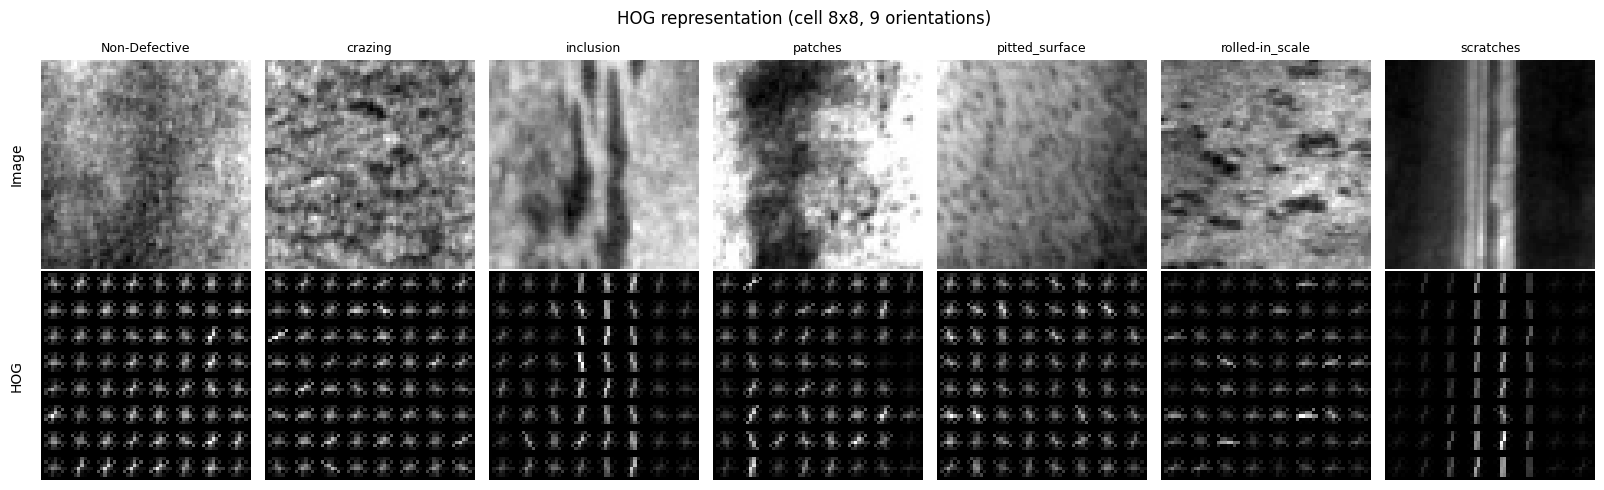

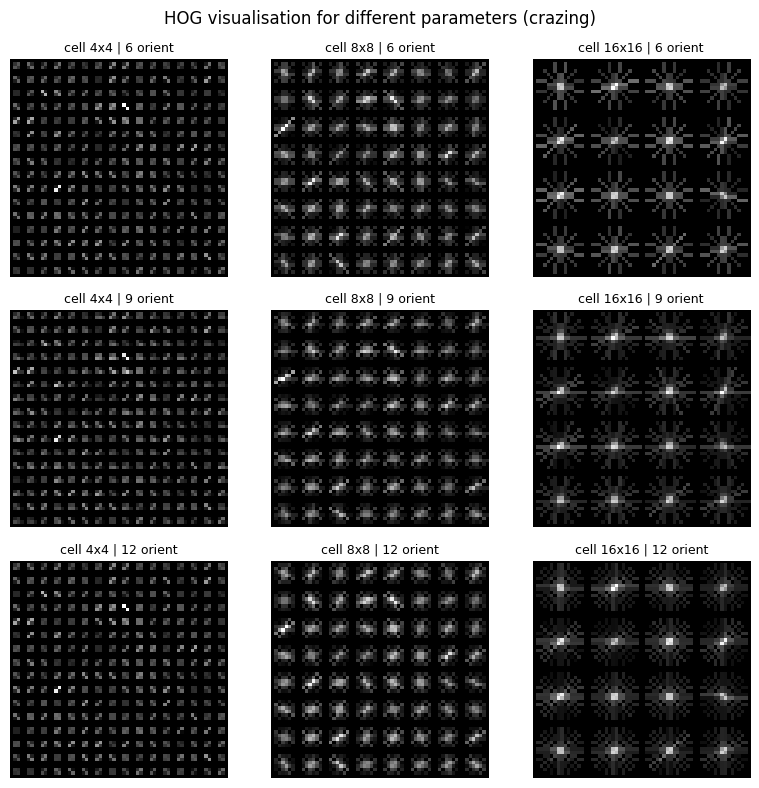

In [ ]:
def hog_one(img, cell=BASE_CELL, orient=BASE_ORIENT, block=BLOCK, visualize=False):
    return hog(img, orientations=orient, pixels_per_cell=(cell, cell), cells_per_block=(block, block),
               block_norm="L2-Hys", transform_sqrt=True, feature_vector=True, visualize=visualize)

def extract_hog(imgs, cell=BASE_CELL, orient=BASE_ORIENT):
    return np.asarray([hog_one(im, cell, orient) for im in imgs], dtype=np.float32)

f = hog_one(X_train_img[0])
print("HOG feature length (cell 8x8, 9 orientations):", f.shape[0])

# ---- visualise HOG for one representative image per defect type + a normal patch ----
reps = [("Non-Defective", int(np.where(y_train == 0)[0][0]))]
for c in sorted(meta_train.cls[meta_train.kind == "defect"].unique()):
    reps.append((c, int(np.where((meta_train.cls == c) & (meta_train.kind == "defect"))[0][0])))

fig, axes = plt.subplots(2, len(reps), figsize=(2.3 * len(reps), 5))
for j, (name, i) in enumerate(reps):
    _, hog_img = hog_one(X_train_img[i], visualize=True)
    axes[0][j].imshow(X_train_img[i], cmap="gray"); axes[0][j].set_title(name, fontsize=9); axes[0][j].axis("off")
    axes[1][j].imshow(exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max() + 1e-9)), cmap="gray"); axes[1][j].axis("off")
axes[0][0].text(-0.08, 0.5, "Image", rotation=90, transform=axes[0][0].transAxes, ha="right", va="center")
axes[1][0].text(-0.08, 0.5, "HOG", rotation=90, transform=axes[1][0].transAxes, ha="right", va="center")
plt.suptitle("HOG representation (cell 8x8, 9 orientations)"); plt.tight_layout(); savefig("hog_samples.png"); plt.show()

# ---- effect of HOG parameters on the representation (one defective patch) ----
i = reps[1][1]
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for r, o in enumerate(ORIENTATIONS):
    for c, cs in enumerate(CELL_SIZES):
        _, hi = hog_one(X_train_img[i], cs, o, visualize=True)
        axes[r][c].imshow(exposure.rescale_intensity(hi, in_range=(0, hi.max() + 1e-9)), cmap="gray"); axes[r][c].axis("off")
        axes[r][c].set_title(f"cell {cs}x{cs} | {o} orient", fontsize=9)
plt.suptitle(f"HOG visualisation for different parameters ({reps[1][0]})"); plt.tight_layout(); savefig("hog_params.png"); plt.show()

## 5. Classifiers, Comparison, Confusion Matrices & Metrics (Tasks 6–10)

Baseline HOG configuration: **8×8 cells, 9 orientations**. Classifiers:
1. **SVM (RBF kernel)** – required
2. **SVM (Linear)**
3. **Random Forest** – additional classifier
4. **Logistic Regression** – additional classifier

All use `class_weight="balanced"` because the two classes are not equally frequent. Positive class = *Defective*.

Feature matrix: (5425, 1764) (1374, 1764)


,Accuracy,Precision,Recall,F1-score,Train time (s),Inference (ms/patch)
Classifier,,,,,,
SVM (RBF),0.7918,0.8328,0.8404,0.8366,27.2775,5.9527
SVM (Linear),0.7183,0.8176,0.7153,0.7630,2.6220,0.0038
Random Forest,0.8042,0.8028,0.9162,0.8558,54.5246,0.0559
Logistic Regression,0.7562,0.8463,0.7520,0.7964,3.4923,0.0050


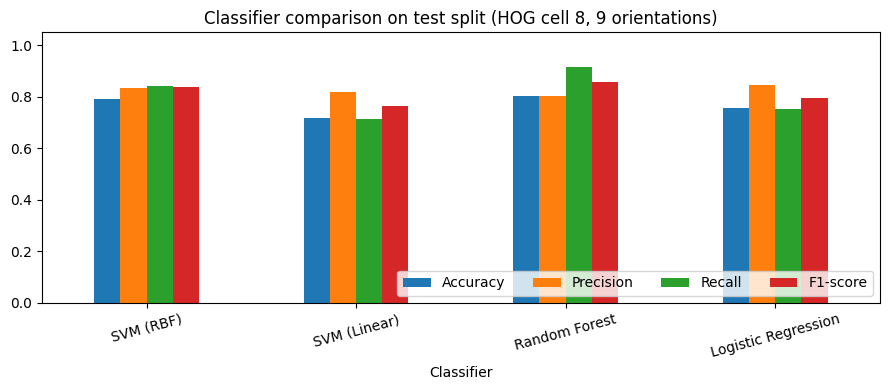

In [23]:
def get_models():
    return {
        "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=SEED),
        "SVM (Linear)":        LinearSVC(C=0.1, class_weight="balanced", max_iter=10000, random_state=SEED),
        "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=SEED),
        "Logistic Regression": LogisticRegression(C=10, max_iter=3000, class_weight="balanced", random_state=SEED),
    }

def metrics(y_true, y_pred, average="binary"):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, average=average, zero_division=0),
            "F1-score":  f1_score(y_true, y_pred, average=average, zero_division=0)}

_feat_cache = {}
def feats(cell, orient):
    # HOG features for train and test patches (cached per configuration)
    if (cell, orient) not in _feat_cache:
        _feat_cache[(cell, orient)] = (extract_hog(X_train_img, cell, orient), extract_hog(X_test_img, cell, orient))
    return _feat_cache[(cell, orient)]

Xtr, Xte = feats(BASE_CELL, BASE_ORIENT)
print("Feature matrix:", Xtr.shape, Xte.shape)

trained, rows, preds = {}, [], {}
for name, model in get_models().items():
    t0 = time.time(); model.fit(Xtr, y_train); fit_t = time.time() - t0
    t0 = time.time(); p = model.predict(Xte); pred_t = (time.time() - t0) / len(Xte) * 1000
    trained[name], preds[name] = model, p
    rows.append({"Classifier": name, **metrics(y_test, p), "Train time (s)": fit_t, "Inference (ms/patch)": pred_t})

comparison = pd.DataFrame(rows).set_index("Classifier")
display(comparison.style.format("{:.4f}").highlight_max(subset=["Accuracy", "Precision", "Recall", "F1-score"], color="#40ad55"))

ax = comparison[["Accuracy", "Precision", "Recall", "F1-score"]].plot.bar(figsize=(9, 4), rot=15, ylim=(0, 1.05))
ax.set_title(f"Classifier comparison on test split (HOG cell {BASE_CELL}, {BASE_ORIENT} orientations)")
ax.legend(loc="lower right", ncol=4); plt.tight_layout(); savefig("model_comparison.png"); plt.show()

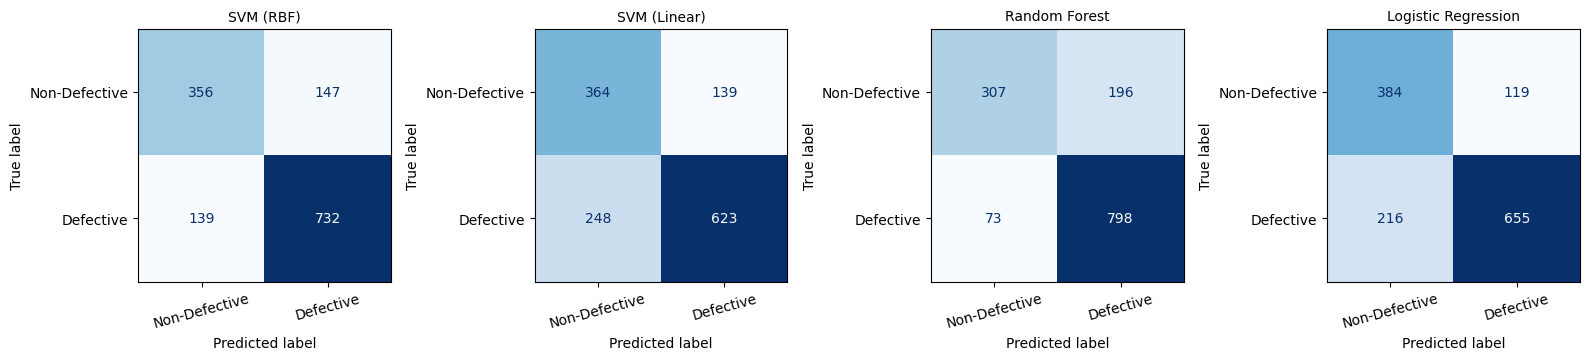

SVM (RBF)
               precision    recall  f1-score   support

Non-Defective     0.7192    0.7078    0.7134       503
    Defective     0.8328    0.8404    0.8366       871

     accuracy                         0.7918      1374
    macro avg     0.7760    0.7741    0.7750      1374
 weighted avg     0.7912    0.7918    0.7915      1374

SVM (Linear)
               precision    recall  f1-score   support

Non-Defective     0.5948    0.7237    0.6529       503
    Defective     0.8176    0.7153    0.7630       871

     accuracy                         0.7183      1374
    macro avg     0.7062    0.7195    0.7080      1374
 weighted avg     0.7360    0.7183    0.7227      1374

Random Forest
               precision    recall  f1-score   support

Non-Defective     0.8079    0.6103    0.6954       503
    Defective     0.8028    0.9162    0.8558       871

     accuracy                         0.8042      1374
    macro avg     0.8054    0.7633    0.7756      1374
 weighted avg     0.

In [ ]:
# ---- confusion matrices (all classifiers) ----
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for a, (name, p) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p), display_labels=CLASS_NAMES).plot(ax=a, colorbar=False, cmap="Blues", values_format="d")
    a.set_title(name, fontsize=10); a.tick_params(axis="x", labelrotation=15)
plt.tight_layout(); savefig("confusion_matrices.png"); plt.show()

# ---- classification report for every classifier ----
for name, p in preds.items():
    print("=" * 60, f"\n{name}\n" + "=" * 60)
    print(classification_report(y_test, p, target_names=CLASS_NAMES, digits=4))

## 6. Effect of HOG Parameters (Task 11 – Required Experiments)

Full grid: **cell size ∈ {4×4, 8×8, 16×16}** × **orientations ∈ {6, 9, 12}**, evaluated with **HOG + SVM (RBF)** and **HOG + Random Forest**.
To avoid tuning on the test set, models are trained on the *sub-train* part of the training split and scored on the held-out *validation* part; the best configuration is then used for the final model.

SVM (RBF)      cell  4 orient  6 -> F1 0.8312  acc 0.7942  (74.9s)
Random Forest  cell  4 orient  6 -> F1 0.8555  acc 0.8082  (70.1s)
SVM (RBF)      cell  4 orient  9 -> F1 0.8211  acc 0.7821  (98.5s)
Random Forest  cell  4 orient  9 -> F1 0.8489  acc 0.7998  (80.9s)
SVM (RBF)      cell  4 orient 12 -> F1 0.8273  acc 0.7831  (165.9s)
Random Forest  cell  4 orient 12 -> F1 0.8368  acc 0.7737  (70.5s)
SVM (RBF)      cell  8 orient  6 -> F1 0.8370  acc 0.8045  (9.4s)
Random Forest  cell  8 orient  6 -> F1 0.8503  acc 0.8073  (30.6s)
SVM (RBF)      cell  8 orient  9 -> F1 0.8293  acc 0.7914  (17.0s)
Random Forest  cell  8 orient  9 -> F1 0.8521  acc 0.8063  (40.4s)
SVM (RBF)      cell  8 orient 12 -> F1 0.8345  acc 0.7961  (24.7s)
Random Forest  cell  8 orient 12 -> F1 0.8571  acc 0.8101  (41.8s)
SVM (RBF)      cell 16 orient  6 -> F1 0.8279  acc 0.7980  (1.5s)
Random Forest  cell 16 orient  6 -> F1 0.8603  acc 0.8212  (12.2s)
SVM (RBF)      cell 16 orient  9 -> F1 0.8306  acc 0.7980  (3.0

,Classifier,Cell,Orientations,Feature length,Accuracy,Precision,Recall,F1-score,Train time (s)
0,SVM (RBF),4x4,6,5400,0.7942,0.8180,0.8447,0.8312,74.9
1,Random Forest,4x4,6,5400,0.8082,0.7801,0.9472,0.8555,70.1
2,SVM (RBF),4x4,9,8100,0.7821,0.8087,0.8339,0.8211,98.5
3,Random Forest,4x4,9,8100,0.7998,0.7754,0.9379,0.8489,80.9
4,SVM (RBF),4x4,12,10800,0.7831,0.7915,0.8665,0.8273,165.9
5,Random Forest,4x4,12,10800,0.7737,0.7373,0.9674,0.8368,70.5
6,SVM (RBF),8x8,6,1176,0.8045,0.8370,0.8370,0.8370,9.4
7,Random Forest,8x8,6,1176,0.8073,0.7957,0.9130,0.8503,30.6
8,SVM (RBF),8x8,9,1764,0.7914,0.8144,0.8447,0.8293,17.0
9,Random Forest,8x8,9,1764,0.8063,0.7861,0.9301,0.8521,40.4


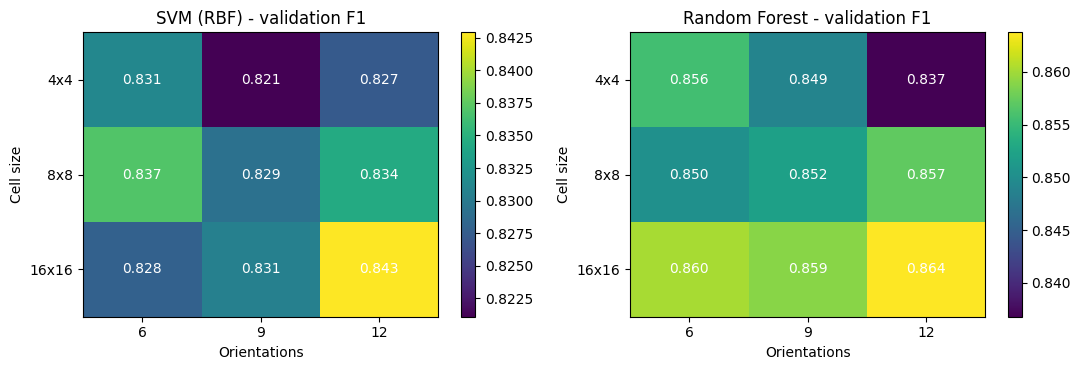


Best HOG configuration for SVM (by validation F1): cell 16x16, 12 orientations


In [ ]:
grid_rows = []
for cell, orient in itertools.product(CELL_SIZES, ORIENTATIONS):
    Xa, _ = feats(cell, orient)
    for name in ["SVM (RBF)", "Random Forest"]:
        model = get_models()[name]
        t0 = time.time(); model.fit(Xa[sub_idx], y_train[sub_idx]); ft = time.time() - t0
        m = metrics(y_train[val_idx], model.predict(Xa[val_idx]))
        grid_rows.append({"Classifier": name, "Cell": f"{cell}x{cell}", "Orientations": orient, "Feature length": Xa.shape[1],
                          **m, "Train time (s)": ft})
        print(f"{name:14s} cell {cell:>2} orient {orient:>2} -> F1 {m['F1-score']:.4f}  acc {m['Accuracy']:.4f}  ({ft:.1f}s)")

grid = pd.DataFrame(grid_rows)
display(grid.style.format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1-score": "{:.4f}", "Train time (s)": "{:.1f}"}))

# heat-maps of validation F1
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for a, name in zip(axes, ["SVM (RBF)", "Random Forest"]):
    pv = grid[grid.Classifier == name].pivot(index="Cell", columns="Orientations", values="F1-score").loc[[f"{c}x{c}" for c in CELL_SIZES]]
    im = a.imshow(pv.values, cmap="viridis", aspect="auto"); a.set_title(f"{name} - validation F1")
    a.set_xticks(range(len(pv.columns)), pv.columns); a.set_yticks(range(len(pv.index)), pv.index)
    a.set_xlabel("Orientations"); a.set_ylabel("Cell size")
    for (i, j), v in np.ndenumerate(pv.values): a.text(j, i, f"{v:.3f}", ha="center", va="center", color="w", fontsize=10)
    plt.colorbar(im, ax=a)
plt.tight_layout(); savefig("hog_grid_heatmap.png"); plt.show()

best_row = grid[grid.Classifier == "SVM (RBF)"].sort_values(["F1-score", "Accuracy"], ascending=False).iloc[0]
BEST_CELL, BEST_ORIENT = int(best_row.Cell.split("x")[0]), int(best_row.Orientations)
print(f"\nBest HOG configuration for SVM (by validation F1): cell {BEST_CELL}x{BEST_CELL}, {BEST_ORIENT} orientations")

## 7. Final Model: HOG + SVM with Best Parameters (Tasks 9 & 10)

FINAL MODEL - HOG (cell 16x16, 12 orient) + SVM (RBF)
  Accuracy  : 0.8020
  Precision : 0.8407
  Recall    : 0.8485
  F1-score  : 0.8446
  ROC-AUC   : 0.8785

Classification report:
                precision    recall  f1-score   support

Non-Defective     0.7333    0.7217    0.7275       503
    Defective     0.8407    0.8485    0.8446       871

     accuracy                         0.8020      1374
    macro avg     0.7870    0.7851    0.7860      1374
 weighted avg     0.8014    0.8020    0.8017      1374



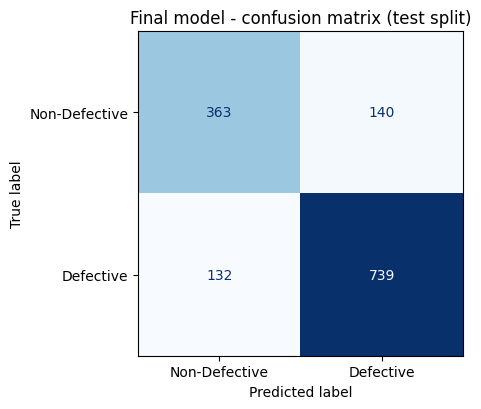

TN=363  FP=140 (good product rejected)  FN=132 (defect missed!)  TP=739

Random Forest at the same HOG configuration: {'Accuracy': 0.8042, 'Precision': 0.7974, 'Recall': 0.9265, 'F1-score': 0.8571}


In [ ]:
Xtr_b, Xte_b = feats(BEST_CELL, BEST_ORIENT)

final_svm = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", probability=True, random_state=SEED)
final_svm.fit(Xtr_b, y_train)
y_pred = final_svm.predict(Xte_b)
y_prob = final_svm.predict_proba(Xte_b)[:, 1]

final_metrics = metrics(y_test, y_pred)
final_metrics["ROC-AUC"] = roc_auc_score(y_test, y_prob)
print(f"FINAL MODEL - HOG (cell {BEST_CELL}x{BEST_CELL}, {BEST_ORIENT} orient) + SVM (RBF)")
for k, v in final_metrics.items(): print(f"  {k:10s}: {v:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Final model - confusion matrix (test split)"); plt.tight_layout(); savefig("confusion_final.png"); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp} (good product rejected)  FN={fn} (defect missed!)  TP={tp}")

# a stronger additional classifier at the same best configuration, used in the robustness study
final_rf = get_models()["Random Forest"].fit(Xtr_b, y_train)
rf_metrics = metrics(y_test, final_rf.predict(Xte_b))
print("\nRandom Forest at the same HOG configuration:", {k: round(v, 4) for k, v in rf_metrics.items()})

## 8. Advanced: Multi-class Defect Classification (6 defect types)

Whole 200×200 images are converted to grayscale, resized to 128×128 (twice the patch size, so the cell size is doubled to keep the same cell grid) and classified into the six NEU defect types.

Multi-class features: (1440, 432) (360, 432)


,Accuracy,Macro Precision,Macro Recall,Macro F1
Classifier,,,,
SVM (RBF),0.9083,0.9122,0.9083,0.9081
Random Forest,0.8861,0.8898,0.8861,0.8841


Best multi-class model: SVM (RBF)

                 precision    recall  f1-score   support

        crazing     0.9355    0.9667    0.9508        60
      inclusion     0.8889    0.9333    0.9106        60
        patches     0.7826    0.9000    0.8372        60
 pitted_surface     0.9200    0.7667    0.8364        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     0.9464    0.8833    0.9138        60

       accuracy                         0.9083       360
      macro avg     0.9122    0.9083    0.9081       360
   weighted avg     0.9122    0.9083    0.9081       360



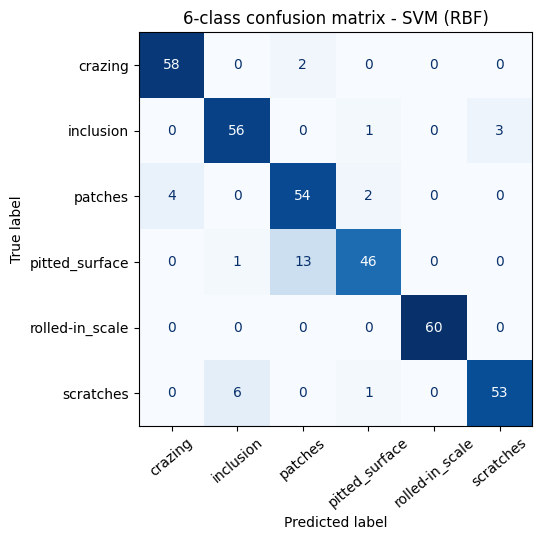

In [ ]:
MC_SIZE = IMG_SIZE * 2
def load_gray(p, size=MC_SIZE): return preprocess(cv2.imread(p), size)

tr_df, te_df = df[df.split == "train"], df[df.split == "valid"]
class_list = sorted(df.cls.unique()); cls2id = {c: i for i, c in enumerate(class_list)}
Xtr_mc = extract_hog([load_gray(p) for p in tr_df.path], BEST_CELL * 2, BEST_ORIENT)
Xte_mc = extract_hog([load_gray(p) for p in te_df.path], BEST_CELL * 2, BEST_ORIENT)
ytr_mc = tr_df.cls.map(cls2id).values; yte_mc = te_df.cls.map(cls2id).values
print("Multi-class features:", Xtr_mc.shape, Xte_mc.shape)

mc_rows, mc_preds = [], {}
for name in ["SVM (RBF)", "Random Forest"]:
    m = get_models()[name].fit(Xtr_mc, ytr_mc); p = m.predict(Xte_mc); mc_preds[name] = p
    mc_rows.append({"Classifier": name, **metrics(yte_mc, p, average="macro")})
mc_table = pd.DataFrame(mc_rows).set_index("Classifier")
mc_table.columns = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
display(mc_table.style.format("{:.4f}"))

best_mc = mc_table["Macro F1"].idxmax()
print(f"Best multi-class model: {best_mc}\n")
print(classification_report(yte_mc, mc_preds[best_mc], target_names=class_list, digits=4))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(confusion_matrix(yte_mc, mc_preds[best_mc]), display_labels=class_list).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=40)
ax.set_title(f"6-class confusion matrix - {best_mc}"); plt.tight_layout(); savefig("confusion_multiclass.png"); plt.show()

## 9. Robustness Experiments (Task 12)

The models are trained **once on clean images** and evaluated on perturbed *test* patches under four realistic imaging conditions
(brightness variation, Gaussian noise, rotation, blur – each at three severities). We report accuracy / F1 and their change from the clean baseline.
Finally, we test whether **augmentation-based training** improves robustness.

In [ ]:
rob_rng = np.random.default_rng(SEED)

def f_bright(alpha=1.0, beta=0): return lambda im: cv2.convertScaleAbs(im, alpha=alpha, beta=beta)
def f_noise(sigma):              return lambda im: np.clip(im.astype(np.float32) + rob_rng.normal(0, sigma, im.shape), 0, 255).astype(np.uint8)
def f_rot(angle):
    def fn(im):
        h, w = im.shape; M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        return cv2.warpAffine(im, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    return fn
def f_blur(k): return lambda im: cv2.GaussianBlur(im, (k, k), 0)

CONDITIONS = {
    "Brightness x0.6": ("Brightness", f_bright(0.6, 0)), "Brightness x1.4": ("Brightness", f_bright(1.4, 0)), "Brightness +40": ("Brightness", f_bright(1.0, 40)),
    "Noise sigma=5":   ("Gaussian noise", f_noise(5)),   "Noise sigma=15":  ("Gaussian noise", f_noise(15)),  "Noise sigma=30": ("Gaussian noise", f_noise(30)),
    "Rotation 5 deg":  ("Rotation", f_rot(5)),           "Rotation 15 deg": ("Rotation", f_rot(15)),          "Rotation 30 deg": ("Rotation", f_rot(30)),
    "Blur k=3":        ("Blur", f_blur(3)),              "Blur k=5":        ("Blur", f_blur(5)),             "Blur k=9":       ("Blur", f_blur(9)),
}

def eval_on(model, imgs):
    p = model.predict(extract_hog(imgs, BEST_CELL, BEST_ORIENT))
    return metrics(y_test, p)

# keep perturbed test sets so that every model sees identical corrupted images
perturbed = {name: np.array([fn(im) for im in X_test_img]) for name, (cat, fn) in CONDITIONS.items()}

def robustness_table(models):
    out = []
    base = {n: eval_on(m, X_test_img) for n, m in models.items()}
    for n in models:
        out.append({"Condition": "Clean (baseline)", "Category": "-", "Model": n,
                    "Accuracy": base[n]["Accuracy"], "F1-score": base[n]["F1-score"], "dAcc": 0.0, "dF1": 0.0})
    for cname, (cat, _) in CONDITIONS.items():
        for n, m in models.items():
            r = eval_on(m, perturbed[cname])
            out.append({"Condition": cname, "Category": cat, "Model": n, "Accuracy": r["Accuracy"], "F1-score": r["F1-score"],
                        "dAcc": r["Accuracy"] - base[n]["Accuracy"], "dF1": r["F1-score"] - base[n]["F1-score"]})
    return pd.DataFrame(out)

rob = robustness_table({"HOG+SVM": final_svm, "HOG+RF": final_rf})
rob_view = rob.pivot_table(index=["Category", "Condition"], columns="Model", values=["Accuracy", "F1-score", "dAcc", "dF1"], sort=False)
display(rob_view.style.format("{:+.4f}", subset=[c for c in rob_view.columns if c[0].startswith("d")]).format("{:.4f}", subset=[c for c in rob_view.columns if not c[0].startswith("d")]))

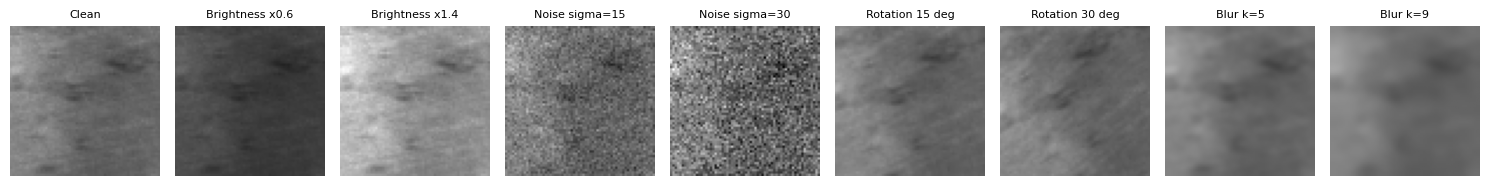

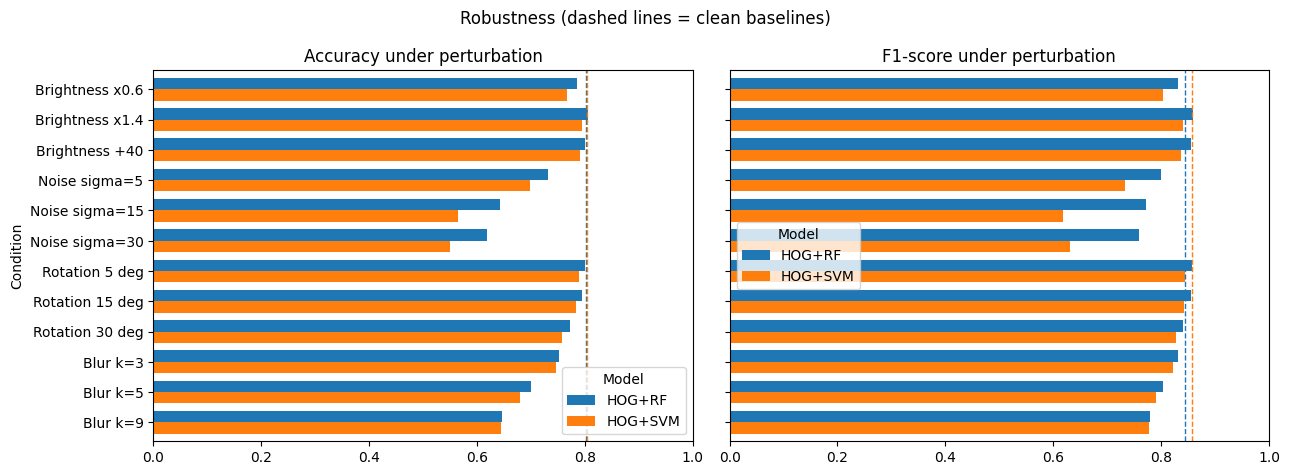

In [ ]:
# ---- example perturbed images ----
show = ["Brightness x0.6", "Brightness x1.4", "Noise sigma=15", "Noise sigma=30", "Rotation 15 deg", "Rotation 30 deg", "Blur k=5", "Blur k=9"]
i0 = int(np.where(y_test == 1)[0][3])
fig, axes = plt.subplots(1, len(show) + 1, figsize=(15, 2.2))
axes[0].imshow(X_test_img[i0], cmap="gray", vmin=0, vmax=255); axes[0].set_title("Clean", fontsize=8)
for a, n in zip(axes[1:], show): a.imshow(perturbed[n][i0], cmap="gray", vmin=0, vmax=255); a.set_title(n, fontsize=8)
for a in axes: a.axis("off")
plt.tight_layout(); savefig("perturbation_examples.png"); plt.show()

# ---- accuracy / F1 under each condition ----
plot_df = rob[rob.Condition != "Clean (baseline)"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for a, metric in zip(axes, ["Accuracy", "F1-score"]):
    pv = plot_df.pivot(index="Condition", columns="Model", values=metric).loc[list(CONDITIONS)]
    pv.plot.barh(ax=a, width=0.75); a.invert_yaxis(); a.set_xlim(0, 1.0); a.set_title(f"{metric} under perturbation")
    for m, col in zip(["HOG+SVM", "HOG+RF"], ["C0", "C1"]):
        a.axvline(rob[(rob.Condition == "Clean (baseline)") & (rob.Model == m)][metric].iloc[0], color=col, ls="--", lw=1)
plt.suptitle("Robustness (dashed lines = clean baselines)"); plt.tight_layout(); savefig("robustness.png"); plt.show()

# ---- mean degradation per category ----
cat_summary = plot_df.groupby(["Category", "Model"])[["dAcc", "dF1"]].mean().unstack("Model")
display(cat_summary.style.format("{:+.4f}"))

In [ ]:
# ---- can augmentation-based training make the system more robust? ----
aug_rng = np.random.default_rng(SEED + 1)
fns = [fn for _, (_, fn) in CONDITIONS.items()]
X_aug_img = np.array([fns[aug_rng.integers(len(fns))](im) for im in X_train_img])
X_train_aug = np.vstack([Xtr_b, extract_hog(X_aug_img, BEST_CELL, BEST_ORIENT)]); y_train_aug = np.concatenate([y_train, y_train])

svm_aug = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=SEED).fit(X_train_aug, y_train_aug)
rob_aug = robustness_table({"HOG+SVM (augmented training)": svm_aug})

cmp_rows = []
for cname in ["Clean (baseline)"] + list(CONDITIONS):
    a = rob[(rob.Condition == cname) & (rob.Model == "HOG+SVM")].iloc[0]; b = rob_aug[(rob_aug.Condition == cname)].iloc[0]
    cmp_rows.append({"Condition": cname, "F1 (clean-trained)": a["F1-score"], "F1 (augmented-trained)": b["F1-score"], "Gain": b["F1-score"] - a["F1-score"]})
aug_cmp = pd.DataFrame(cmp_rows).set_index("Condition")
display(aug_cmp.style.format("{:+.4f}", subset=["Gain"]).format("{:.4f}", subset=["F1 (clean-trained)", "F1 (augmented-trained)"]))

,F1 (clean-trained),F1 (augmented-trained),Gain
Condition,,,
Clean (baseline),0.8446,0.8313,-0.0133
Brightness x0.6,0.8032,0.7942,-0.0090
Brightness x1.4,0.8407,0.8349,-0.0059
Brightness +40,0.8365,0.8270,-0.0095
Noise sigma=5,0.7324,0.7471,+0.0147
Noise sigma=15,0.6181,0.6369,+0.0188
Noise sigma=30,0.6313,0.6179,-0.0134
Rotation 5 deg,0.8445,0.8441,-0.0005
Rotation 15 deg,0.8419,0.8381,-0.0038


## 10. Industrial Quality-Control Decision Module (Task 13)

`inspect_patch` classifies a single image patch; `inspect_image` inspects a **whole product image** with a sliding window (80×80 windows, stride 40) and rejects the product if at least `MIN_DEFECT_WINDOWS` windows are predicted defective with probability ≥ `DEFECT_THRESHOLD`.
Output follows the format required by the lab. The trained model is saved to `outputs/hog_svm_defect_model.joblib`.


--- test patch #5 (true label: Defective) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 86.3%
Action: REJECT PRODUCT

--- test patch #25 (true label: Non-Defective) ---
PRODUCT INSPECTION RESULT
Prediction: NON-DEFECTIVE
Confidence: 96.4%
Action: ACCEPT PRODUCT

--- pitted_surface_65.jpg (true type: pitted_surface) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 81.2%
Action: REJECT PRODUCT

--- crazing_282.jpg (true type: crazing) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 70.2%
Action: REJECT PRODUCT

--- pitted_surface_101.jpg (true type: pitted_surface) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 76.6%
Action: REJECT PRODUCT

--- inclusion_123.jpg (true type: inclusion) ---
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 88.9%
Action: REJECT PRODUCT


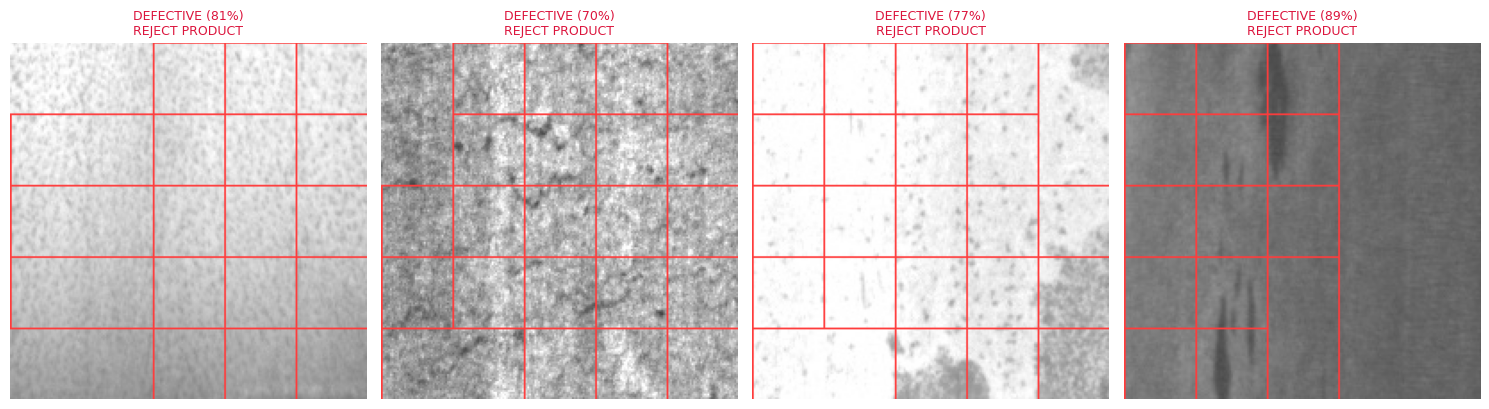


Image-level reject rate on 100 defective validation images: 99.0%  |  inspection time: 30.3 ms / image
Patch-level latency (preprocess + HOG + SVM): 2.28 ms


In [21]:
BUNDLE = dict(model=final_svm, cell=BEST_CELL, orient=BEST_ORIENT, img_size=IMG_SIZE, win=WIN)
joblib.dump(BUNDLE, os.path.join(OUT_DIR, "hog_svm_defect_model.joblib"))

DEFECT_THRESHOLD = 0.50      # probability above which a window is called defective
MIN_DEFECT_WINDOWS = 2       # windows needed to reject a whole product image
STRIDE = 40

def make_result(prob_defect, threshold=DEFECT_THRESHOLD):
    if prob_defect >= threshold:
        return {"prediction": "DEFECTIVE", "confidence": 100 * prob_defect, "action": "REJECT PRODUCT"}
    return {"prediction": "NON-DEFECTIVE", "confidence": 100 * (1 - prob_defect), "action": "ACCEPT PRODUCT"}

def print_result(res):
    print("PRODUCT INSPECTION RESULT")
    print(f"Prediction: {res['prediction']}")
    print(f"Confidence: {res['confidence']:.1f}%")
    print(f"Action: {res['action']}")

def inspect_patch(img, show=True):
    # Inspect ONE patch (grayscale or BGR array, any size)
    g = preprocess(img)
    p = BUNDLE["model"].predict_proba(hog_one(g, BUNDLE["cell"], BUNDLE["orient"])[None])[0, 1]
    res = make_result(p)
    if show: print_result(res)
    return res

def inspect_image(img_bgr, stride=STRIDE, show=True):
    # Inspect a WHOLE product image with a sliding window
    H, W = img_bgr.shape[:2]; w = min(WIN, H, W)
    coords = [(x, y) for y in range(0, H - w + 1, stride) for x in range(0, W - w + 1, stride)]
    F = np.asarray([hog_one(preprocess(img_bgr[y:y + w, x:x + w]), BUNDLE["cell"], BUNDLE["orient"]) for x, y in coords])
    probs = BUNDLE["model"].predict_proba(F)[:, 1]
    flagged = probs >= DEFECT_THRESHOLD
    if flagged.sum() >= MIN_DEFECT_WINDOWS:
        res = {"prediction": "DEFECTIVE", "confidence": 100 * probs[flagged].mean(), "action": "REJECT PRODUCT"}
    else:
        res = {"prediction": "NON-DEFECTIVE", "confidence": 100 * (1 - probs).mean(), "action": "ACCEPT PRODUCT"}
    res.update(windows=[(x, y, w, p) for (x, y), p in zip(coords, probs)], n_flagged=int(flagged.sum()))
    if show: print_result(res)
    return res

# ---- demo 1: single patches from the test split ----
for lab in (1, 0):
    i = int(np.where(y_test == lab)[0][5]); print(f"\n--- test patch #{i} (true label: {CLASS_NAMES[lab]}) ---"); inspect_patch(X_test_img[i])

# ---- demo 2: whole product images ----
demo = te_df.sample(4, random_state=SEED)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for a, (_, row) in zip(axes, demo.iterrows()):
    img = cv2.imread(row.path); print(f"\n--- {os.path.basename(row.path)} (true type: {row.cls}) ---")
    res = inspect_image(img); vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for (x, y, w, p) in res["windows"]:
        if p >= DEFECT_THRESHOLD: cv2.rectangle(vis, (x, y), (x + w, y + w), (255, 60, 60), 1)
    a.imshow(vis); a.axis("off"); a.set_title(f"{res['prediction']} ({res['confidence']:.0f}%)\n{res['action']}", fontsize=9,
                                                color="crimson" if res["prediction"] == "DEFECTIVE" else "green")
plt.tight_layout(); savefig("decision_demo.png"); plt.show()

# ---- system-level check on whole test images (all NEU images contain a defect, so reject-rate = image-level recall) ----
chk = te_df.sample(min(100, len(te_df)), random_state=SEED)
t0 = time.time(); rej = [inspect_image(cv2.imread(p), show=False)["action"] == "REJECT PRODUCT" for p in chk.path]
ms_img = (time.time() - t0) / len(chk) * 1000
IMG_LEVEL_RECALL = float(np.mean(rej))
print(f"\nImage-level reject rate on {len(chk)} defective validation images: {100*IMG_LEVEL_RECALL:.1f}%  |  inspection time: {ms_img:.1f} ms / image")

# single-patch latency
t0 = time.time()
for i in range(100): inspect_patch(X_test_img[i], show=False)
PATCH_MS = (time.time() - t0) / 100 * 1000
print(f"Patch-level latency (preprocess + HOG + SVM): {PATCH_MS:.2f} ms")

## 11. Bonus: Real-Time Webcam / Video Prototype

Each frame is converted to grayscale, rescaled so that the steel surface appears at the scale the model was trained on, scanned with the sliding HOG window and labelled **PASS** or **DEFECTIVE**.
* `run_realtime(source=0)` opens a webcam (or a video path) in a window – use it **locally** (press `q` to quit).
* A standalone script `outputs/realtime_hog_inspection.py` is also written, using the saved `.joblib` model.
* A **simulated stream** below runs the same per-frame code on test images so the prototype can be demonstrated even where there is no camera (e.g. Colab).

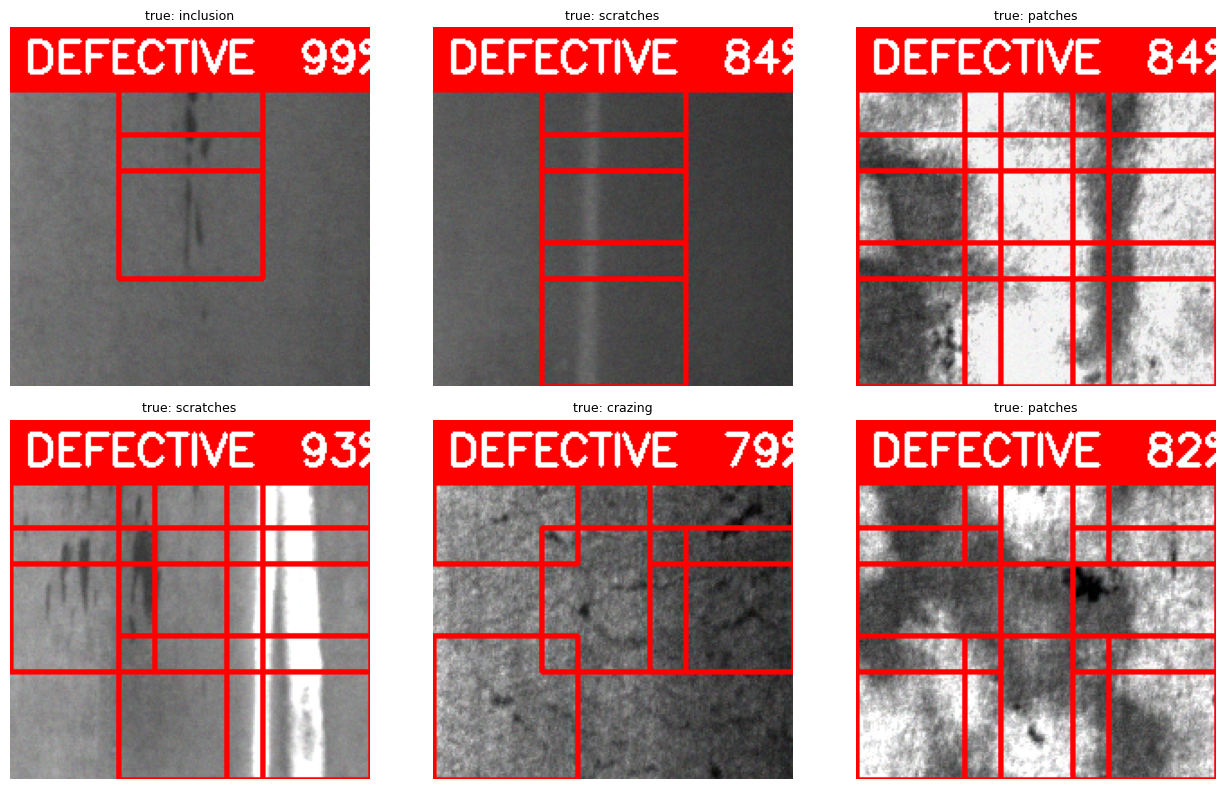

Simulated stream throughput: 3.3 frames/s (CPU)


In [22]:
def inspect_frame(frame_bgr, ref=200, stride=60):
    # per-frame inference: rescale so the short side == ref px, then sliding-window HOG + SVM
    h, w = frame_bgr.shape[:2]; s = ref / min(h, w)
    small = cv2.resize(frame_bgr, (max(WIN, int(w * s)), max(WIN, int(h * s))), interpolation=cv2.INTER_AREA)
    res = inspect_image(small, stride=stride, show=False)
    res["status"] = "DEFECTIVE" if res["prediction"] == "DEFECTIVE" else "PASS"
    return res, s

def annotate(frame_bgr, res, s, fps=None):
    out = frame_bgr.copy(); bad = res["status"] == "DEFECTIVE"; col = (0, 0, 255) if bad else (0, 170, 0)
    for (x, y, w, p) in res["windows"]:
        if p >= DEFECT_THRESHOLD: cv2.rectangle(out, (int(x / s), int(y / s)), (int((x + w) / s), int((y + w) / s)), (0, 0, 255), 2)
    cv2.rectangle(out, (0, 0), (out.shape[1], 36), col, -1)
    txt = f"{res['status']}  {res['confidence']:.0f}%" + (f"   {fps:.1f} FPS" if fps else "")
    cv2.putText(out, txt, (8, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    return out

def run_realtime(source=0, max_frames=None):
    # Webcam / video prototype. Press 'q' to quit. Needs a desktop session (cv2.imshow).
    cap = cv2.VideoCapture(source)
    if not cap.isOpened(): print("Cannot open video source", source); return
    n, t_prev = 0, time.time()
    while True:
        ok, frame = cap.read()
        if not ok: break
        res, s = inspect_frame(frame)
        fps = 1 / max(time.time() - t_prev, 1e-6); t_prev = time.time()
        cv2.imshow("HOG Industrial Inspection", annotate(frame, res, s, fps))
        n += 1
        if (cv2.waitKey(1) & 0xFF == ord("q")) or (max_frames and n >= max_frames): break
    cap.release(); cv2.destroyAllWindows()

# ---- simulated stream: test images with mild noise + brightness jitter, as a camera would deliver ----
sim = te_df.sample(6, random_state=7); sim_rng = np.random.default_rng(3)
fig, axes = plt.subplots(2, 3, figsize=(13, 8)); t0 = time.time()
for a, (_, row) in zip(axes.ravel(), sim.iterrows()):
    fr = cv2.imread(row.path).astype(np.float32)
    fr = np.clip(fr * sim_rng.uniform(0.9, 1.1) + sim_rng.normal(0, 4, fr.shape), 0, 255).astype(np.uint8)
    res, s = inspect_frame(fr); a.imshow(cv2.cvtColor(annotate(fr, res, s), cv2.COLOR_BGR2RGB)); a.axis("off"); a.set_title(f"true: {row.cls}", fontsize=9)
plt.tight_layout(); savefig("realtime_demo.png"); plt.show()
print(f"Simulated stream throughput: {6 / (time.time() - t0):.1f} frames/s (CPU)")
# To try the webcam locally:  run_realtime(0)     or a video file:  run_realtime("video.mp4")

## 12. Export & Download Important Artifacts

Use the cell below to quickly download the trained model bundle and all visual evaluation assets generated throughout the pipeline.

In [24]:
import shutil
from google.colab import files

# 1. Download the trained HOG+SVM model bundle directly
print("Downloading model bundle...")
files.download('outputs/hog_svm_defect_model.joblib')

# 2. Package all generated plot images into a zip and download
print("Zipping and downloading pipeline plots...")
shutil.make_archive('industrial_inspection_plots', 'zip', 'outputs')
files.download('industrial_inspection_plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Zipping and downloading pipeline plots...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>